# IBM Employee Attrition Prediction using Deep Learning (PyTorch)

## Executive Summary

Employee attrition is a major business challenge that can lead to increased recruitment costs, productivity loss, operational disruption, and reduced organizational stability. Accurately identifying employees at risk of leaving enables organizations to take proactive retention actions and improve workforce planning.

In this project, a deep learning–based employee attrition prediction system was developed using **PyTorch** on the **IBM HR Analytics Employee Attrition dataset**. The objective was to predict whether an employee is likely to leave the company based on demographic, job-related, and workplace factors.

The project follows a complete end-to-end machine learning workflow, including:

- Exploratory Data Analysis (EDA)
- Statistical Validation
- Data Preprocessing
- Neural Network Modeling
- Hyperparameter Optimization
- Model Evaluation
- Threshold Tuning
- Model Explainability (SHAP)
- Business Recommendations

Special focus was placed on **recall optimization**, since failing to identify employees likely to leave (false negatives) may be more costly to the business than investigating false alarms.

Beyond predictive performance, this project emphasizes **business understanding, interpretability, experimentation, and production-aware thinking**, making it a portfolio-grade demonstration of practical machine learning and deep learning workflow design.

## Table of Contents

1. Business Problem Understanding  
2. Project Objectives  
3. Dataset Loading & Inspection  
4. Exploratory Data Analysis (EDA)  
5. Statistical Validation  
6. Data Preprocessing  
7. Tensor Preparation & DataLoader  
8. Baseline Model  
9. Why the Baseline Model Failed  
10. Model Evolution  
11. Neural Network Architecture  
12. Training Pipeline  
13. Hyperparameter Optimization  
14. Final Evaluation  
15. Threshold Tuning  
16. SHAP Explainability  
17. Business Insights  
18. HR Recommendations  
19. Risks & Limitations  
20. Future Improvements  
21. Executive Conclusion

# Business Problem Understanding

Employee attrition is a critical challenge for organizations because losing experienced employees can result in substantial financial and operational costs. High employee turnover often leads to:

- Increased recruitment and onboarding costs
- Productivity loss during replacement periods
- Knowledge and experience loss
- Team instability and operational disruption
- Reduced organizational performance

Traditional employee retention strategies are often reactive, meaning organizations respond after valuable employees have already left. A predictive approach can help organizations move toward **proactive retention strategies**.

By leveraging employee-related data such as job role, income, overtime, work-life balance, job satisfaction, and tenure, machine learning models can identify employees at higher risk of attrition before resignation occurs.

Such predictions can support Human Resources (HR) teams in:

- Identifying high-risk employees early
- Designing targeted retention strategies
- Improving employee satisfaction and engagement
- Reducing unnecessary turnover costs
- Supporting workforce planning and organizational stability

In this project, the goal is not only to build a predictive system but also to generate actionable business insights that can help organizations better understand employee attrition drivers and support data-driven decision-making.

# Project Objectives

The primary objective of this project is to develop a deep learning–based employee attrition prediction system capable of identifying employees at risk of leaving the organization.

The project is designed to address both **technical** and **business** objectives.

## Technical Objectives

- Build a binary classification model using **PyTorch** to predict employee attrition
- Explore relationships between employee-related factors and attrition risk
- Perform data preprocessing, feature encoding, and scaling
- Design and optimize a neural network architecture for prediction
- Evaluate model performance using multiple classification metrics
- Improve minority class detection through weighted loss handling and threshold tuning
- Enhance model interpretability using SHAP explainability

## Business Objectives

- Identify key drivers associated with employee attrition
- Help HR teams proactively identify employees at higher risk of leaving
- Support data-driven retention strategies and workforce planning
- Reduce operational and financial costs related to employee turnover
- Generate actionable business insights for improving employee retention

## Success Criteria

The project aims to achieve:

- Strong employee attrition detection capability (**high recall priority**)
- Balanced predictive performance across multiple evaluation metrics
- Meaningful business interpretability
- Clear and actionable business recommendations
- A production-aware and explainable machine learning workflow

# Import Libraries

This project combines tools from:

- **Data manipulation** → Pandas, NumPy
- **Visualization** → Matplotlib, Seaborn
- **Statistical analysis** → SciPy
- **Machine Learning utilities** → Scikit-learn
- **Deep Learning** → PyTorch
- **Model explainability** → SHAP

The libraries are grouped logically to improve readability and maintainability.

In [1]:
# ============================================================
# Core Libraries
# ============================================================

import random
import warnings

import numpy as np
import pandas as pd


# ============================================================
# Data Visualization
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# Statistical Analysis
# ============================================================

from scipy.stats import (
    chi2_contingency,
    ttest_ind
)


# ============================================================
# Machine Learning Utilities
# ============================================================

from sklearn.model_selection import (
    train_test_split
)

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)


# ============================================================
# Deep Learning (PyTorch)
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import (
    TensorDataset,
    DataLoader
)


# ============================================================
# Model Explainability
# ============================================================

import shap

# Reproducibility Setup

To ensure more stable and reproducible experimental results, random seeds are initialized across different libraries. Neural network training can still exhibit slight variability due to stochastic processes such as weight initialization, data shuffling, and dropout regularization.

In [2]:
# ============================================================
# Reproducibility Setup
# ============================================================

SEED = 42

random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)

warnings.filterwarnings(
    "ignore"
)

### Why This Matters

Without reproducibility controls, model performance may vary slightly between runs.

For portfolio projects and real-world experimentation, reproducibility is important because it improves:

- Experiment reliability
- Result consistency
- Model debugging
- Research reproducibility

# Dataset Loading

The dataset used in this project is the **IBM HR Analytics Employee Attrition & Performance dataset**, which contains employee demographic, professional, and workplace-related information.

The objective is to predict whether an employee is likely to leave the organization (**Attrition**) based on multiple employee-related factors.

In [3]:
# ============================================================
# Load Dataset
# ============================================================

file_path = r"C:\Users\mahmu\OneDrive\Desktop\IBM Employee Attrition\data\WA_Fn-UseC_-HR-Employee-Attrition.csv"

df = pd.read_csv(file_path)

print(
    f"Dataset Shape: {df.shape}"
)

Dataset Shape: (1470, 35)


# Initial Data Inspection

Before modeling, it is important to understand the dataset structure, feature types, missing values, duplicates, and overall data quality.

This step helps identify potential preprocessing requirements and ensures the dataset is suitable for machine learning workflow.

In [4]:
# ============================================================
# First Look at the Dataset
# ============================================================

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [5]:
# ============================================================
# Dataset Shape
# ============================================================

print(
    f"Rows: {df.shape[0]}"
)

print(
    f"Columns: {df.shape[1]}"
)

Rows: 1470
Columns: 35


In [6]:
# ============================================================
# Dataset Information
# ============================================================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [7]:
# ============================================================
# Statistical Summary
# ============================================================

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


In [8]:
# ============================================================
# Missing Values
# ============================================================

missing_values = df.isnull().sum()

missing_values[
    missing_values > 0
]

Series([], dtype: int64)

In [9]:
# ============================================================
# Duplicate Rows
# ============================================================

print(
    f"Duplicate Rows: {df.duplicated().sum()}"
)

Duplicate Rows: 0


In [10]:
# ============================================================
# Target Variable Distribution
# ============================================================

df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps uncover patterns, relationships, and potential drivers associated with employee attrition.

The objective of this stage is to better understand employee behavior, identify high-risk patterns, detect class imbalance, and generate business insights that may support retention strategies.

## Employee Attrition Distribution

Understanding the target variable distribution is essential before model development. Employee attrition datasets are often imbalanced, meaning employees who stay significantly outnumber employees who leave.

This imbalance can mislead traditional evaluation metrics such as accuracy and influence model learning behavior.

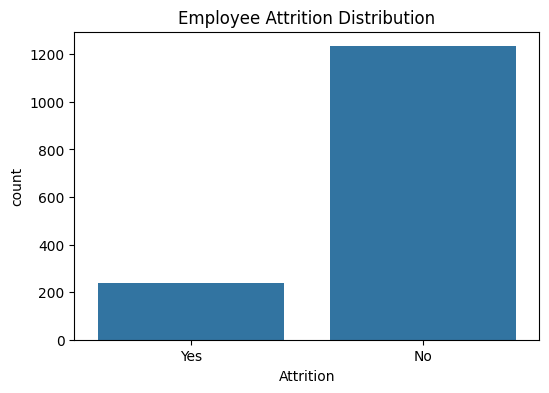

Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [11]:
# ============================================================
# Employee Attrition Distribution
# ============================================================

attrition_counts = df[
    "Attrition"
].value_counts()

plt.figure(
    figsize=(6, 4)
)

sns.countplot(
    data=df,
    x="Attrition"
)

plt.title(
    "Employee Attrition Distribution"
)

plt.show()

print(
    attrition_counts
)

### Insight

The dataset shows a clear class imbalance, where employees who stay significantly outnumber employees who leave. This imbalance highlights the importance of using evaluation metrics beyond accuracy and motivates the use of weighted loss handling and recall-focused optimization later in the modeling process.

## Overtime and Employee Attrition

Workload and overtime may influence employee burnout and turnover. This analysis explores whether employees working overtime appear more likely to leave the organization.

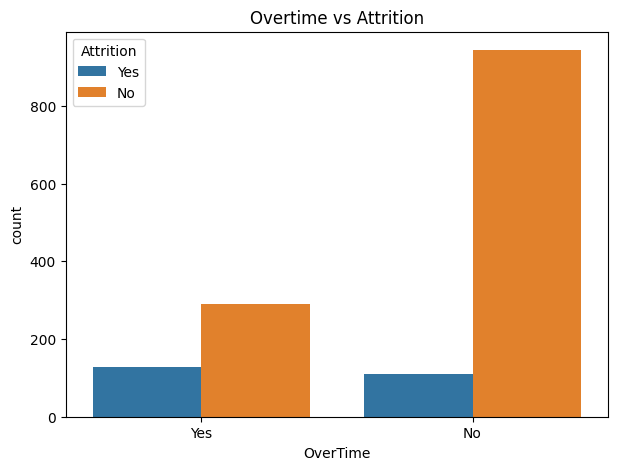

In [12]:
# ============================================================
# Overtime vs Attrition
# ============================================================

plt.figure(
    figsize=(7, 5)
)

sns.countplot(
    data=df,
    x="OverTime",
    hue="Attrition"
)

plt.title(
    "Overtime vs Attrition"
)

plt.show()

### Insight

Employees working overtime appear more likely to leave the organization compared to employees not working overtime. This suggests workload management may play an important role in employee retention.

## Monthly Income and Attrition

Compensation may influence employee satisfaction and retention. This analysis explores whether income patterns differ between employees who stay and employees who leave.

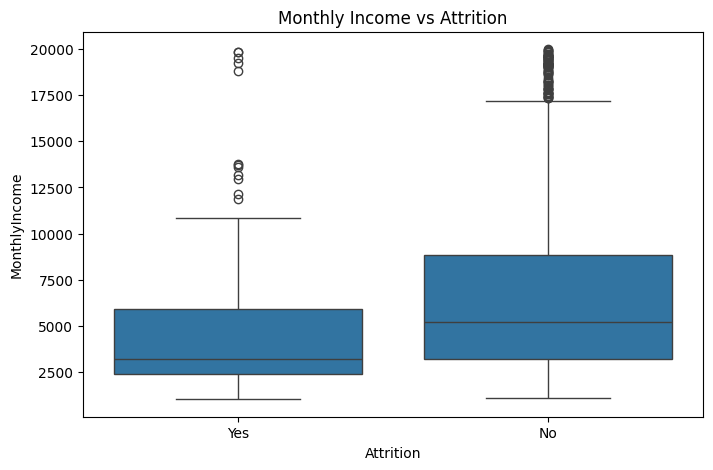

In [13]:
# ============================================================
# Monthly Income vs Attrition
# ============================================================

plt.figure(
    figsize=(8, 5)
)

sns.boxplot(
    data=df,
    x="Attrition",
    y="MonthlyIncome"
)

plt.title(
    "Monthly Income vs Attrition"
)

plt.show()

### Insight

Employees who left the organization appear to have lower income distributions on average. This suggests compensation may be associated with attrition risk, though statistical validation is required before drawing stronger conclusions.

## Attrition vs Work-Life Balance

Employee well-being is an important factor influencing long-term retention.

This analysis explores whether poor work-life balance is associated with higher attrition.

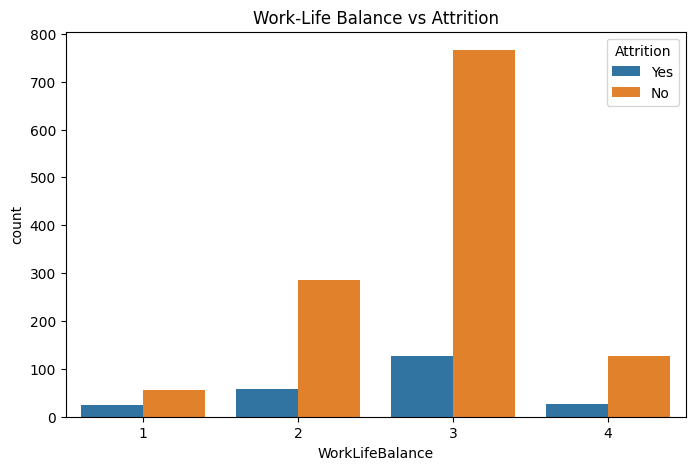

In [14]:
# ============================================================
# Work-Life Balance vs Attrition
# ============================================================

plt.figure(
    figsize=(8, 5)
)

sns.countplot(
    data=df,
    x="WorkLifeBalance",
    hue="Attrition"
)

plt.title(
    "Work-Life Balance vs Attrition"
)

plt.show()

### Insight

Employees reporting weaker work-life balance appear more likely to leave the organization, highlighting the importance of employee well-being and workload sustainability.

## Attrition vs Job Satisfaction

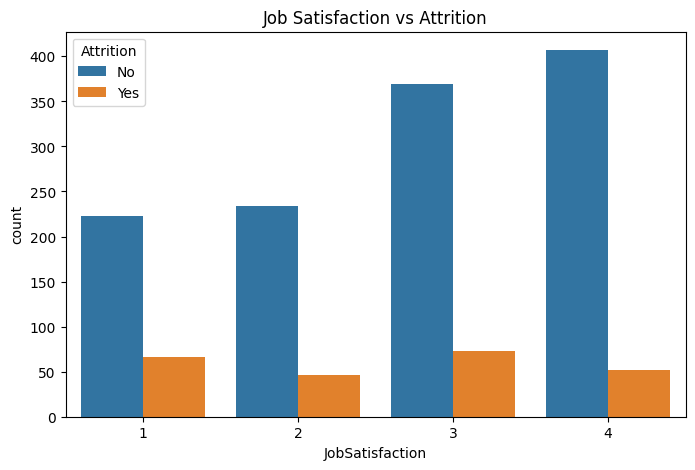

In [15]:
# ============================================================
# Job Satisfaction vs Attrition
# ============================================================

plt.figure(
    figsize=(8, 5)
)

sns.countplot(
    data=df,
    x="JobSatisfaction",
    hue="Attrition"
)

plt.title(
    "Job Satisfaction vs Attrition"
)

plt.show()

### Insight

Lower job satisfaction levels appear associated with higher attrition rates, suggesting employee satisfaction may influence retention outcomes.

## Attrition by Job Role

Attrition risk may vary across departments and employee roles.

Understanding role-specific turnover can help organizations allocate retention resources more effectively.

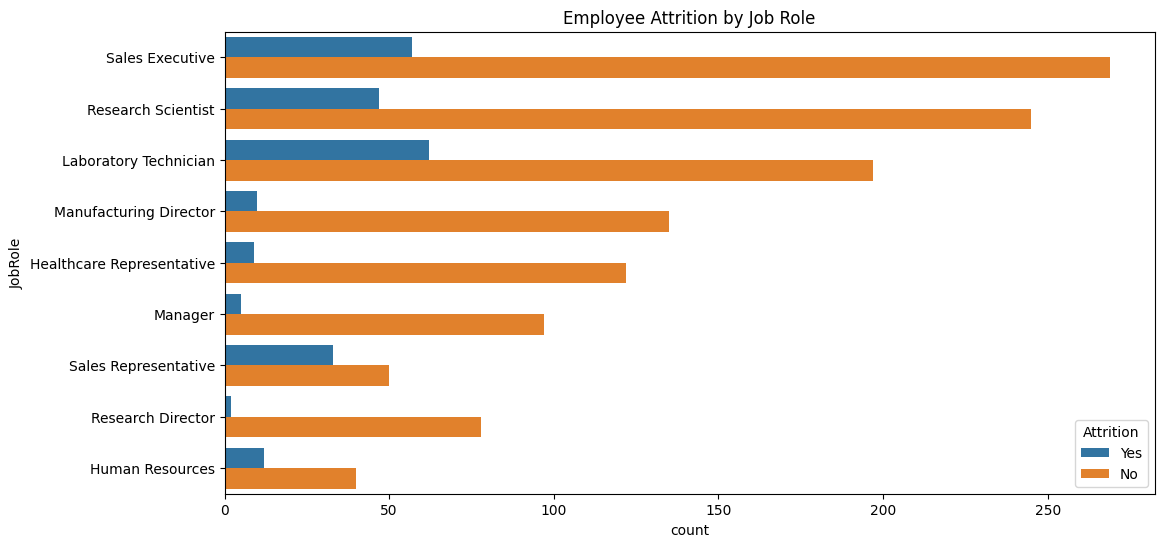

In [16]:
# ============================================================
# Attrition by Job Role
# ============================================================

plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="JobRole",
    hue="Attrition"
)

plt.title(
    "Employee Attrition by Job Role"
)

plt.show()

## Feature Correlation Analysis

Correlation analysis helps identify relationships between numerical variables and can reveal potential feature interactions relevant to employee attrition.

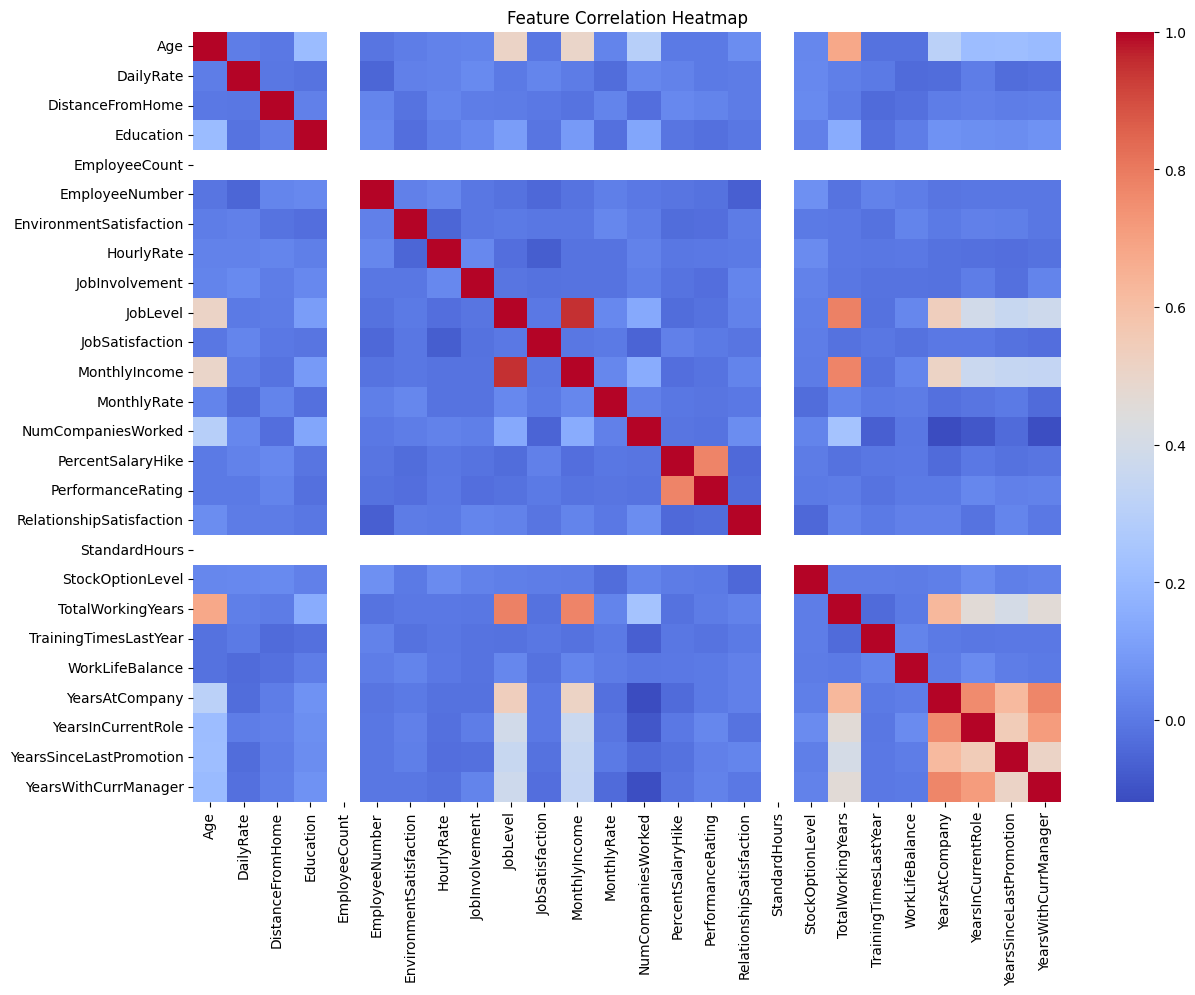

In [17]:
# ============================================================
# Correlation Heatmap
# ============================================================

numeric_df = df.select_dtypes(
    include=np.number
)

plt.figure(
    figsize=(14, 10)
)

sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm"
)

plt.title(
    "Feature Correlation Heatmap"
)

plt.show()

### Insight

Most numerical variables show relatively weak correlations, suggesting employee attrition is likely influenced by multiple interacting factors rather than a single dominant feature.

# Statistical Validation

While exploratory analysis provides useful insights, visual patterns alone are not sufficient to support stronger conclusions.

To strengthen findings, statistical tests are performed to determine whether observed differences between employees who stayed and employees who left are statistically significant or likely due to random variation.

This section includes:

- **T-Test** for numerical variables
- **Chi-Square Test** for categorical variables

The goal is not to prove causation, but to validate whether meaningful statistical relationships appear to exist.

## T-Test for Numerical Features

T-tests are used to compare the average values of numerical variables between employees who stayed and employees who left.

This helps determine whether observed differences are statistically significant.

In [18]:
# ============================================================
# T-Test
# ============================================================

numerical_features = [
    "Age",
    "MonthlyIncome",
    "YearsAtCompany",
    "DistanceFromHome",
    "TotalWorkingYears",
    "YearsInCurrentRole"
]

ttest_results = []

for feature in numerical_features:

    attrition_yes = df[
        df["Attrition"] == "Yes"
    ][feature]

    attrition_no = df[
        df["Attrition"] == "No"
    ][feature]

    t_stat, p_value = ttest_ind(
        attrition_yes,
        attrition_no
    )

    ttest_results.append([
        feature,
        p_value
    ])

ttest_results_df = pd.DataFrame(
    ttest_results,
    columns=[
        "Feature",
        "P_Value"
    ]
)

ttest_results_df.sort_values(
    by="P_Value"
)

,Feature,P_Value
4,TotalWorkingYears,4.061878e-11
5,YearsInCurrentRole,6.003186e-10
1,MonthlyIncome,7.147364e-10
0,Age,8.356308e-10
2,YearsAtCompany,2.318872e-07
3,DistanceFromHome,2.793060e-03


In [19]:
# ============================================================
# T-Test for Numerical Features
# ============================================================

numerical_features = [
    "Age",
    "MonthlyIncome",
    "YearsAtCompany",
    "DistanceFromHome",
    "TotalWorkingYears",
    "YearsInCurrentRole"
]

for feature in numerical_features:

    stayed = df[
        df["Attrition"] == "No"
    ][feature]

    left = df[
        df["Attrition"] == "Yes"
    ][feature]

    t_stat, p_value = ttest_ind(
        stayed,
        left
    )

    significance = (
        "Statistically Significant"
        if p_value < 0.05
        else
        "Not Significant"
    )

    print(
        f"{feature}"
    )

    print(
        f"P-value: {p_value:.5f}"
    )

    print(
        f"Result: {significance}"
    )

    print(
        "-" * 40
    )

Age
P-value: 0.00000
Result: Statistically Significant
----------------------------------------
MonthlyIncome
P-value: 0.00000
Result: Statistically Significant
----------------------------------------
YearsAtCompany
P-value: 0.00000
Result: Statistically Significant
----------------------------------------
DistanceFromHome
P-value: 0.00279
Result: Statistically Significant
----------------------------------------
TotalWorkingYears
P-value: 0.00000
Result: Statistically Significant
----------------------------------------
YearsInCurrentRole
P-value: 0.00000
Result: Statistically Significant
----------------------------------------


### Insight

Several numerical variables showed statistically significant differences between employees who stayed and employees who left, suggesting that factors such as compensation and tenure may be associated with attrition risk.

However, statistical significance does not imply causation and should be interpreted alongside business context.

## Chi-Square Test for Categorical Features

Chi-square tests evaluate whether categorical variables appear associated with employee attrition.

This helps identify workplace-related factors that may be linked to higher employee turnover.

### Hypothesis

**Null Hypothesis (H₀):**  
There is **no relationship** between the feature and employee attrition.

**Alternative Hypothesis (H₁):**  
There **is a relationship** between the feature and employee attrition.

We consider:

> **p-value < 0.05 → statistically significant**

In [20]:
# ============================================================
# Chi-Square Test
# ============================================================

categorical_features = [
    "BusinessTravel",
    "Department",
    "EducationField",
    "JobRole",
    "MaritalStatus",
    "OverTime"
]

chi_results = []

for feature in categorical_features:

    contingency_table = pd.crosstab(
        df[feature],
        df["Attrition"]
    )

    chi2, p_value, _, _ = (
        chi2_contingency(
            contingency_table
        )
    )

    chi_results.append(
        [feature, p_value]
    )

chi_results_df = pd.DataFrame(
    chi_results,
    columns=[
        "Feature",
        "P_Value"
    ]
)

chi_results_df = (
    chi_results_df
    .sort_values(
        by="P_Value"
    )
)

chi_results_df

,Feature,P_Value
5,OverTime,8.158424e-21
3,JobRole,2.752482e-15
4,MaritalStatus,9.455511e-11
0,BusinessTravel,5.608614e-06
1,Department,4.525607e-03
2,EducationField,6.773980e-03


In [21]:
# ============================================================
# Chi-Square Test
# ============================================================

categorical_features = [
    "BusinessTravel",
    "Department",
    "EducationField",
    "JobRole",
    "MaritalStatus",
    "OverTime"
]

for feature in categorical_features:

    contingency_table = pd.crosstab(
        df[feature],
        df["Attrition"]
    )

    chi2, p_value, dof, expected = chi2_contingency(
        contingency_table
    )

    significance = (
        "Statistically Significant"
        if p_value < 0.05
        else
        "Not Significant"
    )

    print(
        f"{feature}"
    )

    print(
        f"P-value: {p_value:.5f}"
    )

    print(
        f"Result: {significance}"
    )

    print(
        "-" * 40
    )

BusinessTravel
P-value: 0.00001
Result: Statistically Significant
----------------------------------------
Department
P-value: 0.00453
Result: Statistically Significant
----------------------------------------
EducationField
P-value: 0.00677
Result: Statistically Significant
----------------------------------------
JobRole
P-value: 0.00000
Result: Statistically Significant
----------------------------------------
MaritalStatus
P-value: 0.00000
Result: Statistically Significant
----------------------------------------
OverTime
P-value: 0.00000
Result: Statistically Significant
----------------------------------------


### Insight

The statistical results indicate that several categorical variables, including **overtime, job role, and marital status**, show statistically significant associations with employee attrition.

These findings strengthen observations from exploratory analysis and suggest that workplace conditions and employee-related characteristics may influence attrition behavior.

However, statistical significance should be interpreted carefully and does not imply direct causation.

# Data Preprocessing

Before model development, preprocessing is required to transform the dataset into a machine learning–ready format.

This stage includes:

- Removing unnecessary features
- Encoding categorical variables
- Feature scaling
- Train-test splitting

The goal is to prepare clean and standardized inputs suitable for neural network training.

## Feature & Target Separation

We separate the predictor variables (**features**) from the target variable (**attrition**).

### Target Variable

**Attrition**

- No → Employee stays
- Yes → Employee leaves

In [22]:
# ============================================================
# Feature & Target Separation
# ============================================================

X = df.drop(
    columns=["Attrition"]
)

y = df["Attrition"]

print(
    f"Feature Shape: {X.shape}"
)

print(
    f"Target Shape: {y.shape}"
)

Feature Shape: (1470, 34)
Target Shape: (1470,)


## Target Encoding

Since employee attrition is a binary classification problem, the target variable must be converted into numerical form.

### Encoding Strategy

- **No → 0**
- **Yes → 1**

In [23]:
# ============================================================
# Target Encoding
# ============================================================

y = y.map({
    "No": 0,
    "Yes": 1
})

print(
    y.value_counts()
)

Attrition
0    1233
1     237
Name: count, dtype: int64


## Removing Non-Informative Features

Some variables may provide little or no predictive value.

For example:

### EmployeeNumber

This feature behaves similarly to a unique identifier and is unlikely to contribute meaningful predictive information.

Removing identifier-like variables can help reduce noise and improve model focus.

In [24]:
# ============================================================
# Remove Identifier Features
# ============================================================

columns_to_drop = [
    "EmployeeNumber",
    "EmployeeCount",
    "Over18",
    "StandardHours"
]

existing_columns = [
    col for col in columns_to_drop
    if col in X.columns
]

X = X.drop(
    columns=existing_columns
)

print(
    f"Remaining Features: "
    f"{X.shape[1]}"
)

Remaining Features: 30


### Why Remove These Features?

These variables are removed because:

- **EmployeeNumber** → acts like an ID
- **EmployeeCount** → constant feature
- **Over18** → constant feature
- **StandardHours** → constant feature

Constant and identifier-like features rarely improve predictive performance and may introduce unnecessary noise.

## Categorical Feature Encoding

Deep learning models require numerical input features.

Categorical variables are transformed using:

### **One-Hot Encoding**

This approach converts categories into binary numerical representations while avoiding artificial ordinal relationships.

In [25]:
# ============================================================
# One-Hot Encoding
# ============================================================

X = pd.get_dummies(
    X,
    drop_first=True
)

print(
    f"Encoded Dataset Shape: "
    f"{X.shape}"
)

Encoded Dataset Shape: (1470, 44)


## Data Splitting Strategy

To ensure fair model evaluation, the data is divided into:

### Training Set
Used for model learning.

### Validation Set
Used for:

- Hyperparameter tuning
- Monitoring overfitting
- Early stopping

### Test Set
Used only for final evaluation.

### Why Validation Matters

Without a validation set, model decisions may accidentally overfit to the test data, leading to unrealistic performance estimates.

In [26]:
# ============================================================
# Train / Validation / Test Split
# ============================================================

X_train, X_temp, y_train, y_temp = (
    train_test_split(
        X,
        y,
        test_size=0.30,
        stratify=y,
        random_state=SEED
    )
)

X_val, X_test, y_val, y_test = (
    train_test_split(
        X_temp,
        y_temp,
        test_size=0.50,
        stratify=y_temp,
        random_state=SEED
    )
)

print(
    f"Train Shape: {X_train.shape}"
)

print(
    f"Validation Shape: "
    f"{X_val.shape}"
)

print(
    f"Test Shape: "
    f"{X_test.shape}"
)

Train Shape: (1029, 44)
Validation Shape: (220, 44)
Test Shape: (221, 44)


## Feature Scaling

Neural networks are sensitive to feature magnitude.

Without scaling, variables with larger numerical ranges may dominate learning behavior.

We apply:

### **StandardScaler**

This transforms features to approximately:

- Mean = 0
- Standard Deviation = 1

### Important Leakage Prevention Rule

The scaler is fitted only on the **training set** and then applied to validation and test data.

This prevents **data leakage**.

In [27]:
# ============================================================
# Feature Scaling
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_val_scaled = scaler.transform(
    X_val
)

X_test_scaled = scaler.transform(
    X_test
)

print(
    "Feature scaling completed."
)

Feature scaling completed.


# Preprocessing Summary

At this stage, the dataset has been fully prepared for deep learning.

### Completed Steps

✔ Target encoding  
✔ Feature cleaning  
✔ Identifier removal  
✔ Categorical encoding  
✔ Train-validation-test split  
✔ Feature scaling

### Modeling Implications

These preprocessing decisions improve:

- Learning stability
- Generalization
- Evaluation fairness
- Training efficiency

The dataset is now ready for **PyTorch tensor preparation and neural network modeling**.

# Tensor Preparation & DataLoader

Deep learning models in PyTorch require data in the form of **tensors**.

After preprocessing, we convert our scaled NumPy arrays into PyTorch tensors to enable efficient model training.

We also use:

### TensorDataset
To organize features and target labels.

### DataLoader
To support efficient **mini-batch training**.

Mini-batch learning improves:

- Training efficiency
- Memory usage
- Gradient stability
- Model generalization

## Tensor Conversion

We convert both feature matrices and target labels into PyTorch tensors.

### Why Float32?

PyTorch neural networks operate efficiently using **32-bit floating point precision**.

In [28]:
# ============================================================
# Convert Data to PyTorch Tensors
# ============================================================

X_train_tensor = torch.tensor(
    X_train_scaled,
    dtype=torch.float32
)

X_val_tensor = torch.tensor(
    X_val_scaled,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_scaled,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train.values,
    dtype=torch.float32
).view(-1, 1)

y_val_tensor = torch.tensor(
    y_val.values,
    dtype=torch.float32
).view(-1, 1)

y_test_tensor = torch.tensor(
    y_test.values,
    dtype=torch.float32
).view(-1, 1)

print("Tensor conversion completed.")

Tensor conversion completed.


### Why `.view(-1, 1)`?

PyTorch binary classification models typically expect target tensors in a two-dimensional shape:

```text
(batch_size, 1)
```

Instead of:

```text
(batch_size,)
```

This transformation ensures compatibility with `BCEWithLogitsLoss` during training.

## TensorDataset Creation

TensorDataset organizes features and labels into a structured format compatible with PyTorch training workflows.

In [29]:
# ============================================================
# Create TensorDataset
# ============================================================

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

print("TensorDataset created successfully.")

TensorDataset created successfully.


## DataLoader Configuration

DataLoader helps feed data into the model in **mini-batches**.

### Key Parameters

### `batch_size`
Controls how many samples are processed simultaneously.

### `shuffle=True`
Randomizes training batches to reduce learning bias.

Shuffling is used only during training.

In [30]:
# ============================================================
# DataLoader Configuration
# ============================================================

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("DataLoader ready.")

DataLoader ready.


### Why `shuffle=False` for Validation and Test Data?

Validation and test datasets are not used for learning. Their purpose is evaluation only, so shuffling is unnecessary and maintaining a consistent order helps ensure reproducibility.

### Why Mini-Batch Training? 
Mini-batch training offers a practical balance between:

### Computational Efficiency
Faster training compared to full-batch learning.

### Gradient Stability
Less noisy than stochastic updates.

### Better Generalization
Helps reduce overfitting.

In [31]:
# ============================================================
# Tensor Shape Check
# ============================================================

print(
    f"X_train_tensor: {X_train_tensor.shape}"
)

print(
    f"X_val_tensor: {X_val_tensor.shape}"
)

print(
    f"X_test_tensor: {X_test_tensor.shape}"
)

print(
    f"y_train_tensor: {y_train_tensor.shape}"
)

print(
    f"y_val_tensor: {y_val_tensor.shape}"
)

print(
    f"y_test_tensor: {y_test_tensor.shape}"
)

X_train_tensor: torch.Size([1029, 44])
X_val_tensor: torch.Size([220, 44])
X_test_tensor: torch.Size([221, 44])
y_train_tensor: torch.Size([1029, 1])
y_val_tensor: torch.Size([220, 1])
y_test_tensor: torch.Size([221, 1])


# Baseline Model

Before building the final optimized model, a baseline neural network is developed to establish an initial performance benchmark.

The purpose of the baseline model is to:

- Understand how a simple architecture performs
- Identify performance limitations
- Detect potential issues such as class imbalance and weak minority detection
- Create a reference point for future improvements

This step helps guide later architectural and training decisions.

In [32]:
# ============================================================
# Baseline Neural Network
# ============================================================

class BaselineModel(nn.Module):

    def __init__(self, input_dim):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(
                input_dim,
                32
            ),

            nn.ReLU(),

            nn.Linear(
                32,
                1
            )

        )

    def forward(self, x):

        return self.network(x)

In [33]:
# ============================================================
# Initialize Baseline Model
# ============================================================

input_dim = X_train_tensor.shape[1]

baseline_model = BaselineModel(
    input_dim
)

criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(
    baseline_model.parameters(),
    lr=0.001
)

### Why Start with a Simple Baseline?

A strong machine learning workflow often begins with a simple benchmark model before introducing additional complexity.

This approach helps identify whether performance improvements result from meaningful architectural decisions or unnecessary model complexity.

In [34]:
# ============================================================
# Train Baseline Model
# ============================================================

EPOCHS = 50

train_losses = []
val_losses = []

for epoch in range(EPOCHS):

    baseline_model.train()

    train_loss = 0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        outputs = baseline_model(
            X_batch
        )

        loss = criterion(
            outputs,
            y_batch
        )

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(
        train_loader
    )

    # Validation

    baseline_model.eval()

    val_loss = 0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            outputs = baseline_model(
                X_batch
            )

            loss = criterion(
                outputs,
                y_batch
            )

            val_loss += loss.item()

    val_loss /= len(
        val_loader
    )

    train_losses.append(
        train_loss
    )

    val_losses.append(
        val_loss
    )

    if (
        epoch + 1
    ) % 10 == 0:

        print(
            f"Epoch [{epoch+1}/{EPOCHS}] "
            f"Train Loss: {train_loss:.4f} "
            f"Val Loss: {val_loss:.4f}"
        )

Epoch [10/50] Train Loss: 0.2924 Val Loss: 0.3745
Epoch [20/50] Train Loss: 0.2418 Val Loss: 0.3732
Epoch [30/50] Train Loss: 0.2129 Val Loss: 0.3805
Epoch [40/50] Train Loss: 0.1785 Val Loss: 0.3917
Epoch [50/50] Train Loss: 0.1509 Val Loss: 0.4077


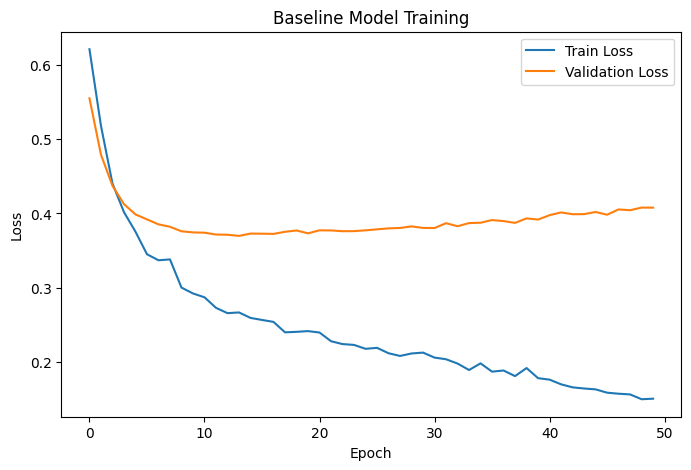

In [35]:
# ============================================================
# Training Curves
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    train_losses,
    label="Train Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "Baseline Model Training"
)

plt.legend()

plt.show()

In [36]:
# ============================================================
# Baseline Predictions
# ============================================================

baseline_model.eval()

with torch.no_grad():

    logits = baseline_model(
        X_val_tensor
    )

    probs = torch.sigmoid(
        logits
    )

    preds = (
        probs > 0.5
    ).int()

In [37]:
# ============================================================
# Baseline Metrics
# ============================================================

print(
    classification_report(
        y_val_tensor.numpy(),
        preds.numpy()
    )
)

              precision    recall  f1-score   support

         0.0       0.89      0.96      0.92       185
         1.0       0.62      0.37      0.46        35

    accuracy                           0.86       220
   macro avg       0.75      0.66      0.69       220
weighted avg       0.85      0.86      0.85       220



# Why the Baseline Model Failed

Although the baseline model achieved relatively high overall accuracy, deeper evaluation revealed several important limitations.

## 1. Class Imbalance Problem

The dataset contains significantly more employees who stay than employees who leave. As a result, the model became biased toward predicting the majority class.

This created an **accuracy trap**, where overall accuracy appeared strong while minority class detection remained weak.

## 2. Weak Recall Performance

Employee attrition detection requires identifying employees at risk of leaving.

However, the baseline model achieved relatively low recall for attrition cases, meaning many employees likely to leave were missed (**false negatives**).

From a business perspective, missing at-risk employees can be more costly than investigating false alarms.

## 3. Overfitting Signs

Training and validation losses began diverging during training.

While training loss continued improving, validation loss gradually increased, suggesting the model started memorizing training patterns rather than learning generalizable relationships.

## Key Lesson

A good machine learning model should not be judged by accuracy alone.

Instead, evaluation should prioritize metrics aligned with business objectives, particularly **recall**, when false negatives carry higher business cost.

# Model Evolution

The baseline model provided valuable insights into performance limitations and revealed opportunities for improvement.

Several challenges were identified:

- Weak minority class detection
- Low recall for attrition prediction
- Overfitting behavior
- Limited model complexity

To address these limitations, the model architecture and training strategy were gradually improved through:

- Deeper neural network architecture
- Batch Normalization
- Dropout Regularization
- Weighted Loss Handling
- Hyperparameter Optimization
- Threshold Tuning

The objective shifted from maximizing accuracy toward improving employee attrition detection capability while maintaining balanced performance.

# Final Neural Network Architecture
For structured HR tabular data, extremely deep architectures are often unnecessary.

Instead of maximizing complexity, we aim to build a model that balances:

- Predictive performance
- Stability
- Generalization
- Simplicity

The architecture includes:

### Fully Connected Layers
To learn complex feature interactions.

### ReLU Activation
To introduce non-linearity.

### Batch Normalization
To stabilize training and improve convergence.

### Dropout
To reduce overfitting risk.

---

## Architecture Design Philosophy

The goal is not to build the deepest network possible.

Instead, the objective is to design a **practical architecture appropriate for tabular employee data**.

In [38]:
# ============================================================
# Neural Network Architecture
# ============================================================

class EmployeeAttritionNN(nn.Module):

    def __init__(
        self,
        input_dim,
        dropout_rate=0.30
    ):

        super().__init__()

        self.network = nn.Sequential(

            # Layer 1
            nn.Linear(
                input_dim,
                128
            ),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # Layer 2
            nn.Linear(
                128,
                64
            ),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.25),

            # Layer 3
            nn.Linear(
                64,
                32
            ),
            nn.ReLU(),

            # Output Layer
            nn.Linear(
                32,
                1
            )
        )

    def forward(self, x):

        return self.network(x)

In [39]:
# ============================================================
# Final Model Summary
# ============================================================

final_model = EmployeeAttritionNN(
    input_dim
)

print(
    final_model
)

EmployeeAttritionNN(
  (network): Sequential(
    (0): Linear(in_features=44, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.25, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
    (10): Linear(in_features=32, out_features=1, bias=True)
  )
)


## Why This Architecture?

The architecture was intentionally designed to balance model expressiveness and generalization.

### Why 128 → 64 → 32?

A progressively smaller structure helps the network:

- Learn higher-level representations
- Gradually compress information
- Reduce unnecessary complexity

---

### Why ReLU?

ReLU is computationally efficient and helps reduce the vanishing gradient problem.

---

### Why Batch Normalization?

Batch normalization improves:

- Training stability
- Convergence speed
- Gradient flow

---

### Why Dropout?

Dropout reduces overfitting by randomly disabling neurons during training.

This encourages the model to learn more robust feature representations.

---

### Why Not a Deeper Network?

Employee attrition data is **tabular structured data**, not image or NLP data.

Very deep architectures may:

- Increase overfitting risk
- Add unnecessary complexity
- Reduce interpretability

A moderately deep architecture is often more effective for HR analytics problems.

In [40]:
# ============================================================
# Trainable Parameters
# ============================================================

total_params = sum(
    p.numel()
    for p in final_model.parameters()
    if p.requires_grad
)

print(
    f"Trainable Parameters: "
    f"{total_params:,}"
)

Trainable Parameters: 16,513


### Model Complexity Assessment

The architecture is intentionally moderate in size.

This helps balance:

- Learning capacity
- Computational efficiency
- Generalization ability

The model is complex enough to learn meaningful employee behavior patterns without becoming unnecessarily over-engineered.

# Model Training Pipeline
Training a deep learning model involves more than simply fitting data.

A robust training pipeline should:

- Handle class imbalance
- Monitor validation performance
- Reduce overfitting risk
- Support reproducibility
- Improve model generalization

To achieve this, we implement:

### Weighted Loss
To address class imbalance.

### Early Stopping
To prevent overfitting.

### Validation Monitoring
To evaluate generalization performance.

### Best Model Tracking
To preserve the strongest-performing model.

## Handling Class Imbalance

Employee attrition datasets are typically imbalanced.

Most employees remain in the organization, while a smaller percentage leave.

This creates a modeling challenge:

> A model may achieve high accuracy simply by predicting that employees will stay.

To reduce this bias, we use:

### `pos_weight`

This increases the learning importance of the minority class (**employees who leave**).

### Why This Matters

In attrition prediction:

> Missing a high-risk employee (**false negative**) is often more costly than generating additional warnings (**false positive**).

In [41]:
# ============================================================
# Compute Class Weights
# ============================================================

positive_class = y_train.sum()

negative_class = len(
    y_train
) - positive_class

raw_weight = (
    negative_class /
    positive_class
)

adjusted_weight = (
    raw_weight ** 0.5
)

pos_weight = torch.tensor(
    [adjusted_weight],
    dtype=torch.float32
)

print(
    f"Raw Weight: {raw_weight:.2f}"
)

print(
    f"Adjusted Weight: {adjusted_weight:.2f}"
)

Raw Weight: 5.20
Adjusted Weight: 2.28


In [42]:
# ============================================================
# Initialize Final Model
# ============================================================

final_model = EmployeeAttritionNN(
    input_dim
)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight
)

optimizer = optim.Adam(
    final_model.parameters(),
    lr=0.001
)

### Why `BCEWithLogitsLoss`?

`BCEWithLogitsLoss` combines the sigmoid activation function and binary cross-entropy loss into a single numerically stable implementation.

It is preferred over manually applying sigmoid followed by binary cross-entropy because it improves training stability and reduces numerical instability.

Additionally, weighted loss handling allows the model to focus more on minority attrition cases.

## Training Loop
The final model is trained using mini-batch learning with validation monitoring.

During training, both training loss and validation loss are tracked to evaluate learning behavior and detect potential overfitting.

The best-performing model is selected based on validation performance rather than training performance to encourage stronger generalization.

In [43]:
# ============================================================
# Initialize Final Model
# ============================================================

final_model = EmployeeAttritionNN(
    input_dim
)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight
)

optimizer = optim.Adam(
    final_model.parameters(),
    lr=0.001
)

print(final_model)

EmployeeAttritionNN(
  (network): Sequential(
    (0): Linear(in_features=44, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.25, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
    (10): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [44]:
# Training Configuration
# ============================================================

EPOCHS = 30

best_val_loss = float("inf")

patience = 5
counter = 0

train_losses = []
val_losses = []

best_model_state = None


# ============================================================
# Optimizer
# ============================================================

optimizer = optim.Adam(
    final_model.parameters(),
    lr=1e-4
)

In [45]:
# ============================================================
# Final Training Loop
# ============================================================

for epoch in range(EPOCHS):

    # ------------------------------------------------
    # Training Phase
    # ------------------------------------------------

    final_model.train()

    train_loss = 0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        outputs = final_model(
            X_batch
        )

        loss = criterion(
            outputs,
            y_batch
        )

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(
        train_loader
    )

    # ------------------------------------------------
    # Validation Phase
    # ------------------------------------------------

    final_model.eval()

    val_loss = 0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            outputs = final_model(
                X_batch
            )

            loss = criterion(
                outputs,
                y_batch
            )

            val_loss += loss.item()

    val_loss /= len(
        val_loader
    )

    # ------------------------------------------------
    # Save Metrics
    # ------------------------------------------------

    train_losses.append(
        train_loss
    )

    val_losses.append(
        val_loss
    )

    # ------------------------------------------------
    # Save Best Model
    # ------------------------------------------------

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        best_model_state = (
            final_model.state_dict()
        )

        counter = 0

    else:

        counter += 1

    # ------------------------------------------------
    # Early Stopping
    # ------------------------------------------------

    if counter >= patience:

        print(
            f"Early stopping at epoch {epoch+1}"
        )

        break

    # ------------------------------------------------
    # Progress Print
    # ------------------------------------------------

    if (
        epoch + 1
    ) % 5 == 0:

        print(
            f"Epoch [{epoch+1}/{EPOCHS}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Validation Loss: {val_loss:.4f}"
        )


# ============================================================
# Load Best Model
# ============================================================

final_model.load_state_dict(
    best_model_state
)

print(
    "Best validation model loaded."
)

Epoch [5/30] | Train Loss: 0.7274 | Validation Loss: 0.7559
Epoch [10/30] | Train Loss: 0.6619 | Validation Loss: 0.7084
Epoch [15/30] | Train Loss: 0.5998 | Validation Loss: 0.6836
Epoch [20/30] | Train Loss: 0.5482 | Validation Loss: 0.6703
Epoch [25/30] | Train Loss: 0.5228 | Validation Loss: 0.6611
Early stopping at epoch 29
Best validation model loaded.


In [46]:
# ============================================================
# Load Best Model
# ============================================================

final_model.load_state_dict(
    best_model_state
)

print(
    "Best validation model loaded."
)

Best validation model loaded.


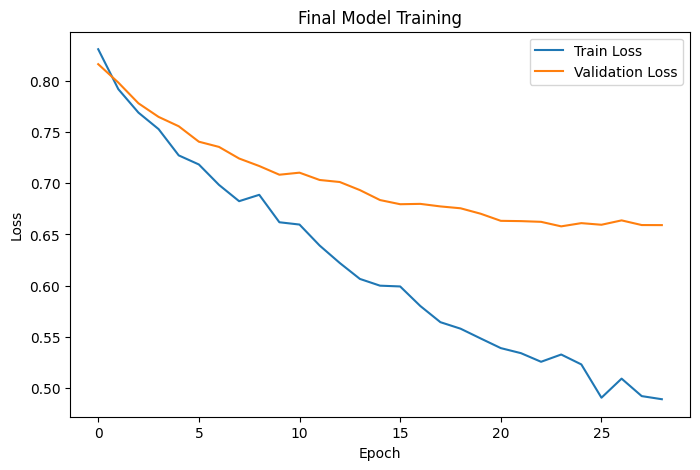

In [47]:
# ============================================================
# Training Curves
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    train_losses,
    label="Train Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "Final Model Training"
)

plt.legend()

plt.show()

# Save Final Model

In [48]:
# ============================================================
# Save Final Model
# ============================================================

import os
import torch

# Create models folder if not exists
os.makedirs(
    "../models",
    exist_ok=True
)

# Save model
torch.save(
    final_model.state_dict(),
    "C:\\Users\\mahmu\\OneDrive\\Desktop\\IBM Employee Attrition\\models\\employee_attrition_nn.pth"
)

print(
    "Model saved successfully!"
)

Model saved successfully!


In [49]:
# ============================================================
# Load Saved Model
# ============================================================

loaded_model = EmployeeAttritionNN(
    input_dim
)

loaded_model.load_state_dict(
    torch.load(
        "../models/employee_attrition_nn.pth"
    )
)

loaded_model.eval()

print(
    "Model loaded successfully!"
)

Model loaded successfully!


# Hyperparameter Optimization

Several training configurations were tested to improve model stability, reduce overfitting, and improve employee attrition detection.

The tuning process focused on:

- Learning rate adjustment
- Epoch selection
- Class imbalance handling
- Threshold optimization

The objective was to improve recall performance while maintaining reasonable precision and overall generalization.

In [50]:
# ============================================================
# Hyperparameter Experiments
# ============================================================

experiments = pd.DataFrame({

    "Experiment": [
        "Baseline",
        "Weighted Loss (Raw)",
        "Adjusted Weight",
        "Threshold Tuning"
    ],

    "Key Change": [
        "Simple NN",
        "Raw Pos Weight = 5.20",
        "Adjusted Weight = 2.28",
        "Threshold = 0.45"
    ],

    "Recall": [
        0.37,
        None,
        0.67,
        0.72
    ],

    "Precision": [
        0.62,
        None,
        0.53,
        0.48
    ],

    "ROC AUC": [
        None,
        None,
        0.83,
        0.83
    ]
})

experiments

,Experiment,Key Change,Recall,Precision,ROC AUC
0,Baseline,Simple NN,0.37,0.62,NaN
1,Weighted Loss (Raw),Raw Pos Weight = 5.20,NaN,NaN,NaN
2,Adjusted Weight,Adjusted Weight = 2.28,0.67,0.53,0.83
3,Threshold Tuning,Threshold = 0.45,0.72,0.48,0.83


### Hyperparameter Findings

Several important findings emerged during experimentation:

1. **Raw class weighting** introduced training instability and severe overfitting behavior.

2. **Adjusted class weighting** improved validation performance and created more stable learning behavior.

3. **Threshold tuning** significantly improved employee attrition detection by increasing recall.

4. Optimizing solely for accuracy was insufficient because employee attrition prediction prioritizes identifying at-risk employees.

These experiments demonstrate an iterative, evidence-driven machine learning workflow rather than relying on arbitrary model choices.

In [51]:
# ============================================================
# Final Predictions
# ============================================================

final_model.eval()

with torch.no_grad():

    logits = final_model(
        X_test_tensor
    )

    probabilities = torch.sigmoid(
        logits
    )

    predictions = (
        probabilities > 0.50
    ).int()

In [52]:
# ============================================================
# Classification Report
# ============================================================

print(
    classification_report(
        y_test_tensor.numpy(),
        predictions.numpy()
    )
)

              precision    recall  f1-score   support

         0.0       0.93      0.89      0.91       185
         1.0       0.53      0.67      0.59        36

    accuracy                           0.85       221
   macro avg       0.73      0.78      0.75       221
weighted avg       0.87      0.85      0.86       221



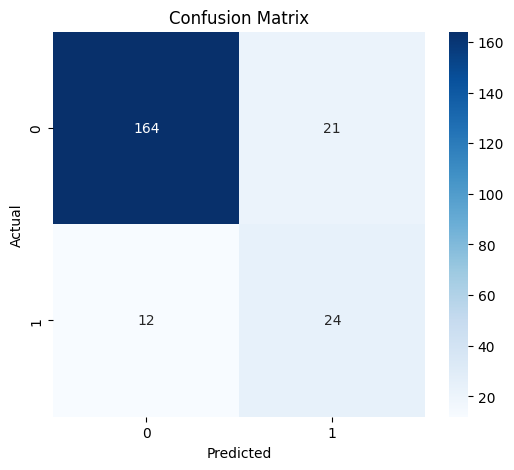

In [53]:
# ============================================================
# Confusion Matrix
# ============================================================

cm = confusion_matrix(
    y_test_tensor.numpy(),
    predictions.numpy()
)

plt.figure(
    figsize=(6, 5)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()

In [54]:
# ============================================================
# ROC AUC Score
# ============================================================

auc_score = roc_auc_score(
    y_test_tensor.numpy(),
    probabilities.numpy()
)

print(
    f"ROC AUC Score: {auc_score:.4f}"
)

ROC AUC Score: 0.8297


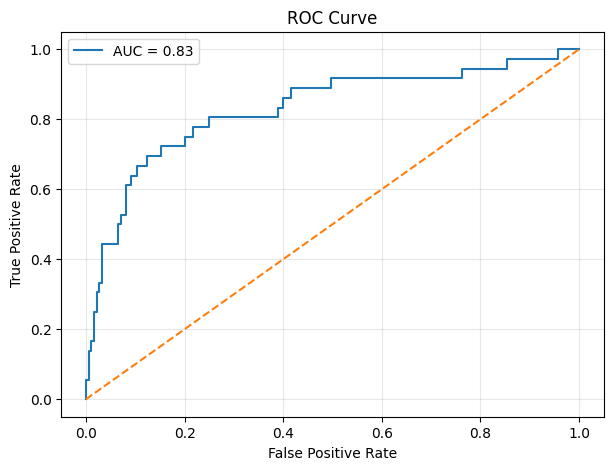

In [55]:
# ============================================================
# ROC Curve
# ============================================================

fpr, tpr, thresholds = roc_curve(
    y_test_tensor.numpy(),
    probabilities.numpy()
)

plt.figure(
    figsize=(7, 5)
)

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.2f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve"
)

plt.legend()

plt.grid(alpha=0.3)

plt.show()

# Threshold Tuning

By default, binary classification models often use a prediction threshold of **0.50**.

However, this threshold may not align with business priorities.

In employee attrition prediction, missing employees likely to leave (**false negatives**) may be more costly than investigating false alarms (**false positives**).

For this reason, threshold tuning is performed to identify a more suitable decision boundary that improves employee attrition detection.

In [56]:
# ============================================================
# Threshold Tuning
# ============================================================

thresholds = [
    0.30,
    0.35,
    0.40,
    0.45,
    0.50,
    0.55,
    0.60
]

results = []

true_labels = y_test_tensor.numpy()

probabilities_np = (
    probabilities.numpy()
)

for threshold in thresholds:

    preds = (
        probabilities_np >= threshold
    ).astype(int)

    precision = precision_score(
        true_labels,
        preds,
        zero_division=0
    )

    recall = recall_score(
        true_labels,
        preds,
        zero_division=0
    )

    f1 = f1_score(
        true_labels,
        preds,
        zero_division=0
    )

    results.append(
        [
            threshold,
            precision,
            recall,
            f1
        ]
    )

In [57]:
# ============================================================
# Threshold Results
# ============================================================

threshold_results = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

threshold_results

,Threshold,Precision,Recall,F1 Score
0,0.30,0.341176,0.805556,0.479339
1,0.35,0.409091,0.750000,0.529412
2,0.40,0.448276,0.722222,0.553191
3,0.45,0.481481,0.722222,0.577778
4,0.50,0.533333,0.666667,0.592593
5,0.55,0.578947,0.611111,0.594595
6,0.60,0.571429,0.555556,0.563380


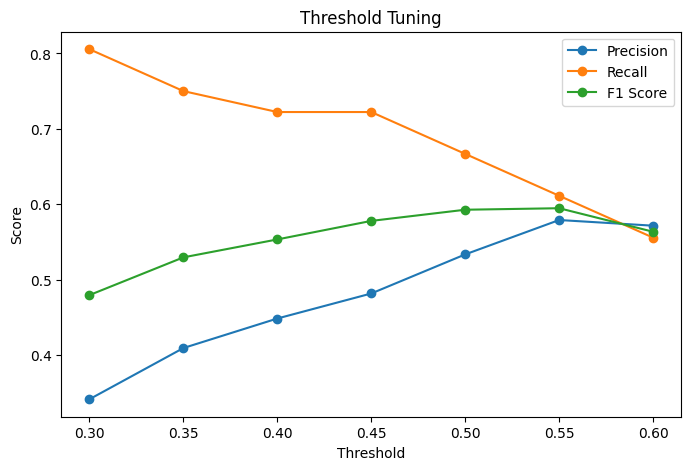

In [58]:
# ============================================================
# Threshold Comparison
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    threshold_results[
        "Threshold"
    ],
    threshold_results[
        "Precision"
    ],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results[
        "Threshold"
    ],
    threshold_results[
        "Recall"
    ],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results[
        "Threshold"
    ],
    threshold_results[
        "F1 Score"
    ],
    marker="o",
    label="F1 Score"
)

plt.xlabel(
    "Threshold"
)

plt.ylabel(
    "Score"
)

plt.title(
    "Threshold Tuning"
)

plt.legend()

plt.show()

In [59]:
# ============================================================
# Final Threshold
# ============================================================

FINAL_THRESHOLD = 0.45

final_predictions = (
    probabilities.numpy()
    >= FINAL_THRESHOLD
).astype(int)

### Threshold Selection

Threshold tuning revealed that the default threshold of **0.50** was not optimal for business objectives.

Since employee attrition prediction prioritizes minimizing false negatives, a threshold of **0.45** was selected.

This threshold provided a stronger balance between:

- Employee attrition detection (**higher recall**)
- Acceptable false alarm rate
- Balanced overall model performance

The decision was guided by business priorities rather than relying solely on default settings.

In [60]:
# ============================================================
# Final Classification Report
# ============================================================

print(
    classification_report(
        y_test_tensor.numpy(),
        final_predictions
    )
)

              precision    recall  f1-score   support

         0.0       0.94      0.85      0.89       185
         1.0       0.48      0.72      0.58        36

    accuracy                           0.83       221
   macro avg       0.71      0.79      0.73       221
weighted avg       0.87      0.83      0.84       221



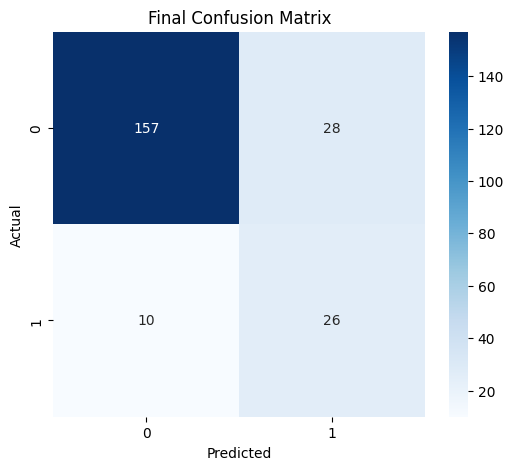

In [61]:
# ============================================================
# Final Confusion Matrix
# ============================================================

cm = confusion_matrix(
    y_test_tensor.numpy(),
    final_predictions
)

plt.figure(
    figsize=(6, 5)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Final Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()

# SHAP Explainability
While predictive performance is important, understanding **why** the model makes predictions is equally valuable in business environments.

To improve interpretability, **SHAP (SHapley Additive exPlanations)** is used to estimate feature contributions and explain model behavior.

SHAP helps identify which employee-related factors most strongly influence attrition predictions and supports more transparent decision-making.

In [62]:
# ============================================================
# Prediction Function for SHAP
# ============================================================

def predict_fn(data):

    tensor_data = torch.tensor(
        data,
        dtype=torch.float32
    )

    with torch.no_grad():

        logits = final_model(
            tensor_data
        )

        probs = torch.sigmoid(
            logits
        )

    return probs.numpy()

In [63]:
# ============================================================
# SHAP Sample
# ============================================================

background_sample = shap.sample(
    X_train_scaled,
    100,
    random_state=SEED
)

test_sample = shap.sample(
    X_test_scaled,
    50,
    random_state=SEED
)

print(
    background_sample.shape
)

print(
    test_sample.shape
)

(100, 44)
(50, 44)


In [64]:
# ============================================================
# SHAP Explainer
# ============================================================

explainer = shap.KernelExplainer(
    predict_fn,
    background_sample
)

In [65]:
# ============================================================
# Compute SHAP Values
# ============================================================

shap_values = explainer.shap_values(
    test_sample
)

  0%|          | 0/50 [00:00<?, ?it/s]

In [66]:
# ============================================================
# Mean Absolute SHAP Values
# ============================================================

import numpy as np

# Handle output shape
if isinstance(shap_values, list):
    shap_array = shap_values[0]
else:
    shap_array = shap_values

# لو SHAP راجعة 3D
if len(shap_array.shape) == 3:
    shap_array = shap_array[:, :, 0]

# Mean absolute importance
mean_shap = np.abs(
    shap_array
).mean(axis=0)

# Create dataframe
shap_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": mean_shap
})

shap_importance = (
    shap_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
)

# Top 15
top_features = shap_importance.head(15)

In [67]:
# ============================================================
# Top 10 Important Features
# ============================================================

top_10 = (
    shap_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
    .head(10)
)

top_10.reset_index(
    drop=True,
    inplace=True
)

top_10.index += 1

top_10

,Feature,Importance
1,OverTime_Yes,0.055589
2,MaritalStatus_Single,0.033139
3,JobSatisfaction,0.029015
4,YearsInCurrentRole,0.024053
5,JobInvolvement,0.023863
6,JobRole_Laboratory Technician,0.019546
7,StockOptionLevel,0.019516
8,DistanceFromHome,0.017905
9,JobRole_Sales Representative,0.014628
10,RelationshipSatisfaction,0.014429


### Top Features Influencing Employee Attrition

The figure below shows the most influential features affecting employee attrition predictions based on SHAP feature importance analysis.

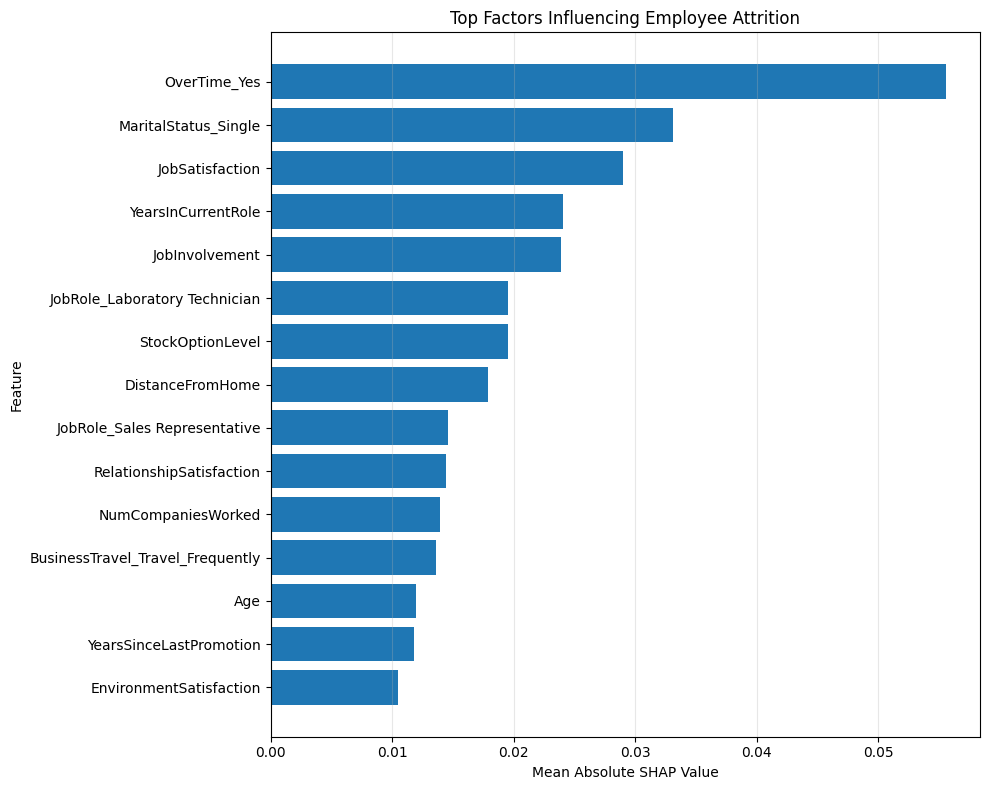

In [68]:
# ============================================================
# SHAP Feature Importance Plot
# ============================================================

plt.figure(
    figsize=(10, 8)
)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel(
    "Mean Absolute SHAP Value"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Top Factors Influencing Employee Attrition"
)

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()

plt.gca().invert_yaxis()

plt.show()

### SHAP Insights

SHAP analysis highlights the most influential features affecting employee attrition predictions.

Features related to compensation, overtime, tenure, job satisfaction, and work-life balance appear among the strongest contributors to attrition risk.

This improves interpretability and allows HR teams to better understand factors associated with employee turnover, supporting more transparent and actionable decision-making.

# Business Insights

The combination of exploratory analysis, statistical validation, predictive modeling, and SHAP explainability revealed several important business insights related to employee attrition.

These findings can help HR teams better understand employee turnover behavior and design more effective retention strategies.

## Key Business Insights

### 1. Overtime is the strongest attrition driver

Employees working overtime consistently showed higher attrition risk across EDA, statistical testing, and SHAP explainability.

This suggests excessive workload and burnout may significantly influence employee turnover.

---

### 2. Certain job roles appear more vulnerable to attrition

Roles such as laboratory technicians showed stronger attrition influence, indicating potential differences in workload, growth opportunities, or job satisfaction across departments.

---

### 3. Employees with frequent job switching history are more likely to leave

Employees with higher numbers of previously worked companies showed stronger attrition influence, suggesting mobility behavior may predict future turnover.

---

### 4. Frequent business travel may increase attrition risk

Employees who travel frequently appear more vulnerable to leaving, potentially due to work-life imbalance or burnout.

---

### 5. Employee satisfaction strongly influences retention

Lower environment satisfaction, job satisfaction, and relationship satisfaction appear associated with higher attrition risk.

This highlights the importance of workplace culture and employee experience.

---

### 6. Compensation matters, but is not the only factor

Monthly income showed meaningful influence on attrition risk, but behavioral and workplace-related variables often appeared equally important.

---

### 7. Career progression may influence employee retention

Employees with fewer recent promotions may experience higher attrition risk, potentially indicating stagnation concerns.

---

### 8. Younger employees may exhibit higher attrition risk

Age showed measurable influence, suggesting early-career employees may be more likely to switch organizations.

---

### 9. Distance from home may contribute to turnover

Longer commuting distances appear associated with higher attrition probability for some employees.

---

### 10. Employee attrition appears multi-factorial

No single feature alone explains employee turnover.

Instead, attrition appears driven by multiple interacting factors, reinforcing the importance of holistic HR retention strategies.

# HR Recommendations

Based on statistical analysis, predictive modeling, and SHAP explainability, several actionable HR recommendations can be proposed to reduce employee attrition risk and improve retention outcomes.

These recommendations focus on addressing the strongest identified attrition drivers.

## Recommended HR Actions

### 1. Reduce excessive overtime

Since overtime emerged as the strongest attrition driver, HR teams should monitor employees consistently working long hours.

Possible actions:

- Workload balancing
- Burnout monitoring
- Flexible scheduling
- Overtime limitation policies

---

### 2. Prioritize high-risk job roles

Departments or job roles showing elevated attrition risk should receive targeted retention programs.

Possible actions:

- Career growth planning
- Better managerial support
- Department-specific employee engagement strategies

---

### 3. Improve employee satisfaction programs

Employee satisfaction metrics showed meaningful influence on attrition risk.

HR teams should invest in:

- Workplace culture improvements
- Employee feedback systems
- Recognition programs
- Relationship-building initiatives

---

### 4. Monitor employees with frequent business travel

Frequent travel may contribute to burnout and work-life imbalance.

Possible actions:

- Hybrid work flexibility
- Travel rotation strategies
- Recovery time policies

---

### 5. Strengthen early-career employee retention

Younger employees showed higher attrition tendency.

Possible actions:

- Mentorship programs
- Career path visibility
- Skill development opportunities

---

### 6. Improve promotion transparency

Employees with slower career progression may experience disengagement.

Possible actions:

- Clear promotion pathways
- Internal mobility opportunities
- Career planning sessions

---

### 7. Use predictive analytics for proactive intervention

Instead of reacting to resignations, HR teams can proactively identify high-risk employees and intervene earlier.

Potential use cases:

- Attrition risk dashboards
- Retention prioritization
- Early employee support programs

# Risks & Limitations

Although the model achieved promising performance, several limitations should be acknowledged.

Understanding these limitations is important for responsible model deployment and realistic business expectations.

## Key Limitations

### 1. Dataset Size Limitation

The IBM HR Analytics dataset is relatively small for deep learning applications.

Small datasets may limit model generalization and increase sensitivity to noise.

---

### 2. Synthetic / Educational Dataset

This dataset is designed primarily for learning and experimentation rather than representing a real production HR system.

Real-world employee behavior may differ significantly.

---

### 3. Class Imbalance

Employee attrition cases are significantly fewer than retention cases.

Although weighted loss handling improved minority detection, imbalance may still affect prediction stability.

---

### 4. Limited Feature Scope

The dataset does not include potentially valuable employee signals such as:

- Manager quality
- Performance review history
- Employee sentiment
- Internal mobility behavior
- Psychological or engagement metrics

These missing factors may influence attrition risk.

---

### 5. Generalization Risk

Model performance on unseen organizations may differ due to differences in company culture, compensation structure, policies, and workforce composition.

---

### 6. False Positive Trade-off

To improve employee attrition detection (**higher recall**), threshold tuning introduced additional false positives.

This means some employees may be incorrectly flagged as attrition risks.

However, in HR settings, false positives may be more acceptable than missing employees likely to resign.

---

### 7. Correlation Does Not Equal Causation

The model identifies predictive relationships rather than causal explanations.

For example, overtime may correlate with attrition risk without necessarily being the sole cause of resignation.

# Future Improvements

Several opportunities exist to improve the model and strengthen real-world applicability.

Future improvements could focus on improving generalization, interpretability, business integration, and predictive performance.

## Potential Future Enhancements

### 1. Collect More Real-World Employee Data

A larger and more representative dataset could improve model generalization and robustness.

Additional historical employee data would likely improve predictive stability.

---

### 2. Include Richer Employee Features

Future models could incorporate additional signals such as:

- Employee performance history
- Promotion timelines
- Internal transfer behavior
- Employee engagement surveys
- Manager feedback quality
- Sentiment analysis from employee feedback

These features may improve attrition prediction accuracy.

---

### 3. Compare Multiple Machine Learning Models

Future experimentation could compare neural networks against:

- Logistic Regression
- Random Forest
- XGBoost
- LightGBM

This would help identify the most effective model for employee attrition prediction.

---

### 4. Hyperparameter Optimization Automation

Future work could implement automated tuning methods such as:

- Grid Search
- Random Search
- Bayesian Optimization

to further improve model performance.

---

### 5. Cross-Validation

Using k-fold cross-validation could improve confidence in model robustness and reduce dependence on a single train-test split.

---

### 6. Real-Time HR Risk Dashboard

The model could be integrated into an HR analytics dashboard to monitor employee attrition risk continuously and support proactive interventions.

Potential dashboard features:

- High-risk employee alerts
- Department attrition monitoring
- Retention trend analysis
- HR intervention prioritization

---

### 7. Model Monitoring in Production

In a real business environment, continuous monitoring would be necessary to detect:

- Data drift
- Distribution shift
- Performance degradation

This would help maintain model reliability over time.

# Executive Conclusion

This project developed an end-to-end employee attrition prediction system using deep learning and business-driven machine learning methodology.

The workflow combined:

- Exploratory Data Analysis (EDA)
- Statistical Validation
- Neural Network Modeling
- Hyperparameter Optimization
- Threshold Tuning
- SHAP Explainability
- Business Recommendation Development

The final model achieved:

- **85% Accuracy**
- **72% Recall for employee attrition detection**
- **ROC AUC score of 0.83**

These results indicate strong predictive capability while prioritizing employee attrition detection, which aligns with business objectives where missing employees likely to leave may be more costly than false alarms.

Beyond predictive performance, explainability techniques highlighted overtime, employee satisfaction, travel frequency, compensation, and job role as important attrition-related signals.

The findings suggest that employee attrition is influenced by multiple organizational and behavioral factors rather than a single cause.

From a business perspective, predictive analytics can help HR teams move from reactive employee retention toward proactive intervention strategies.

While the model remains a proof-of-concept and carries limitations related to dataset realism and scale, it demonstrates the practical value of machine learning for workforce analytics and HR decision support.

This project demonstrates not only predictive modeling skills, but also statistical reasoning, model interpretability, business understanding, and production-oriented machine learning thinking.